In [2]:
##################### Modify Model Inputs #######################
# Super simple script to load in different netCDFs of model 
# inputs so they can be modified in a very simple way, then
# save the updated version as a new input netCDF to be used.
# The purpose of this is to test different settings and things
# in the model (AKA why are there lines...?)
#
# Notes: 
# - 
#
##################################################################

In [3]:
# Load in the modules
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import xroms

### <span style="color:mediumturquoise"> Bathymetry / The Grid </span>

In [ ]:
# Load in the grid file
og_grid = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/grd_500m_span_300km_002.nc')

In [ ]:
# Plot the original bathymetry
og_grid.h.plot()

In [ ]:
# Make a new array that is constant bathymetry but same
# shape as OG
# 20 m constant 
new_const_bathy = np.full_like(og_grid.h, 20.0)

In [ ]:
# Make a copy of the grid file
new_grid = og_grid.copy()

In [ ]:
new_grid.h

In [ ]:
# Set the new bathymetry
new_grid['h'].values = new_const_bathy

In [ ]:
# Plot to see if it worked
new_grid.h.plot()

In [ ]:
# Save to a new netCDF
#new_grid.to_netcdf('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/grd_500m_span_300km_002_constbathy.nc')

### <span style="color:olivedrab"> Initial Conditions </span>

In [3]:
# Load in the initial conditions to be modified
# 500 m, span 300 km, based on make_ini.py
#og_ini = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/ini_ice_500m_span_300km_004.nc')

# 500 m, span 300 km, fixed ubar, based on make_ini.py
og_ini = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/ini_ice_500m_span_300km_004_fixed_ubar.nc')

/tmp/ipykernel_652689/1638552817.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  og_ini = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/ini_ice_500m_span_300km_004_fixed_ubar.nc')


In [4]:
# See what all is in here
og_ini

<xarray.Dataset> Size: 420MB
Dimensions:             (s_rho: 40, eta_rho: 602, xi_rho: 402, ocean_time: 1,
                         eta_u: 602, xi_u: 401, eta_v: 601, xi_v: 402)
Coordinates:
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * xi_rho              (xi_rho) int64 3kB 0 1 2 3 4 5 ... 397 398 399 400 401
  * eta_rho             (eta_rho) int64 5kB 0 1 2 3 4 5 ... 597 598 599 600 601
  * ocean_time          (ocean_time) timedelta64[ns] 8B 00:00:00
Dimensions without coordinates: eta_u, xi_u, eta_v, xi_v
Data variables: (12/22)
    temp                (s_rho, eta_rho, xi_rho) float64 77MB ...
    salt                (s_rho, eta_rho, xi_rho) float64 77MB ...
    u                   (ocean_time, s_rho, eta_u, xi_u) float64 77MB ...
    v                   (ocean_time, s_rho, eta_v, xi_v) float64 77MB ...
    zeta                (ocean_time, eta_rho, xi_rho) float64 2MB ...
    ubar                (ocean_time, eta_u, xi_u) float64 2MB ...
    ...                  ...
    ice_sst             (ocean_time, eta_rho, xi_rho) float64 2MB ...
    ice_Sxx             (ocean_time, eta_rho, xi_rho) float64 2MB ...
    ice_Sxy             (ocean_time, eta_rho, xi_rho) float64 2MB ...
    ice_Syy             (ocean_time, eta_rho, xi_rho) float64 2MB ...
    Uice                (ocean_time, eta_u, xi_u) float64 2MB ...
    Vice                (ocean_time, eta_v, xi_v) float64 2MB ...
Attributes:
    type:         ROMS Ini file
    Description:  Initial conditions for ideal shelf; hc = 100, H_pyc = -50, ...
    Author:       Dylan Schlichting
    Created:      2026-05-18T09:46:41.440539

In [5]:
# Check if all ice variables are already 0 (as they should be I think)
print('Ice thickness')
print(og_ini.ice_thickness.values)

print('Meltpond thickness')
print(og_ini.meltpond_thickness.values)

print('Ice age')
print(og_ini.ice_age.values)

print('Snow Thickness')
print(og_ini.snow_thickness.values)

print('Tice')
print(og_ini.Tice.values)

print('under_ice_temp')
print(og_ini.under_ice_temp.values)

print('under_ice_salt')
print(og_ini.under_ice_salt.values)

print('ice_sst')
print(og_ini.ice_sst.values)

print('ice_Sxx')
print(og_ini.ice_Sxx.values)

print('ice_Sxy')
print(og_ini.ice_Sxy.values)

print('ice_Syy')
print(og_ini.ice_Syy.values)

print('Uice')
print(og_ini.Uice.values)

print('Vice')
print(og_ini.Vice.values)

Ice thickness
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
Meltpond thickness
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
Ice age
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
Snow Thickness
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
Tice
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
under_ice_temp
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0

In [6]:
# Is zeta also 0?
print('zeta')
print(og_ini.zeta.values)

zeta
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]


In [7]:
# Variables to change:
# u, v, ubar, vbar, temp, salt

<span style="color:olivedrab"> **Option 1** </span>  
Make them constant values based on reasonable values?  

Let's make a forcing file where just the currents are constant values and leave salt/temp the same to see if lines go away or not

**Currents**

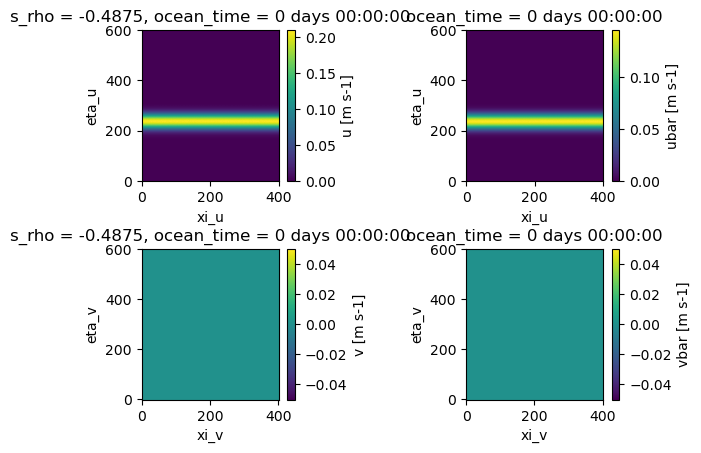

In [8]:
# Plot the currents in the original
fig, ax = plt.subplots(2, 2)

# u currents
og_ini.u[0,20,:,:].plot(ax=ax[0,0])

# ubar
og_ini.ubar[0,:,:].plot(ax=ax[0,1])

# v currents
og_ini.v[0,20,:,:].plot(ax=ax[1,0])

# vbar
og_ini.vbar[0,:,:].plot(ax=ax[1,1])

fig.subplots_adjust(hspace=0.45, wspace=0.89)

<span style="color:firebrick"> **Fix ubar (if needed)** </span>  

In [ ]:
# So let's leave v and vbar as 0, then make u a few things
# For starters, let's fix ubar to actually be calculated from u
# Calculate depth-averaged u current based on u

In [ ]:
# # Load in an output file to use xroms to get cell thickness

# # Set the path to the output
# path = '/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_updated_scratch/roms_his_ice_500m_span_300km_w_dvd_u3c4_keps_v04_0001.nc'

# # Open it using xroms
# ds = xroms.open_netcdf(path)

# # Get fancy grid info using xroms
# model_output, xgrid = xroms.roms_dataset(ds, include_3D_metrics=True)

# # Set the grid to this fancy grid
# model_output.xroms.set_grid(xgrid) 

In [ ]:
# See what all is included in this output
# model_output

In [ ]:
# Pull out cell thickness on u grid to use
# dz_u = model_output['dz_u']

In [ ]:
# print(np.shape(dz_u[0,:,:,:]))
# print(np.shape(og_ini.u[0,:,:,:]))

In [ ]:
# Calculate ubar
# ini_ubar = ((np.sum((og_ini.u[0,:,:,:].values * dz_u[0,:,:,:].values), axis=0)) / xroms.to_u(model_output.h, xgrid))

In [ ]:
# Plot this to see if it worked
# fig, ax = plt.subplots(1, 2)

# # u currents
# og_ini.u[0,20,:,:].plot(ax=ax[0])

# # ubar
# ini_ubar.plot(ax=ax[1])

# fig.subplots_adjust(wspace=0.89)

In [ ]:
# Now save this new ubar profile as the updated initial ubar, then 
# try a run with it 
# Make a ciopy of the original file
# new_ini = og_ini.copy()

In [ ]:
# ini_ubar.shape

In [ ]:
# Make a new version of ubar that has the right shape
# ini_ubar_fix = np.empty((1,602,401))

# Fill with the values
# ini_ubar_fix[0,:,:] = ini_ubar

In [ ]:
# Set the new bathymetry
# new_ini['ubar'].values = ini_ubar_fix

In [ ]:
# Plot this to see if it worked

# new_ini.ubar.plot()

In [ ]:
# Save this new ini conds file
#new_ini.to_netcdf('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/ini_ice_500m_span_300km_004_fixed_ubar.nc')

In [ ]:
# og_ini.z_rho[0,:,200,200].values

In [ ]:
# Load in to see if manual fix worked in make_ini.py
# fixed_ini = xr.open_dataset('/global/u2/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/ini_ice_500m_span_300km_004_TEST.nc')

In [ ]:
# fixed_ini

In [ ]:
# fixed_ini.ubar.plot()

<span style="color:firebrick"> **End ubar fix** </span>  

In [9]:
# Let's try making the currents 0 to start 
# (both u and v) to see if that fixes anything/changes
# the line

# Make new variables that are all 0
ini_u_zero = np.zeros_like(og_ini.u)
ini_ubar_zero = np.zeros_like(og_ini.ubar)
ini_v_zero = np.zeros_like(og_ini.v)
ini_vbar_zero = np.zeros_like(og_ini.vbar)

In [10]:
# Make a copy of the initial conditions to edit
new_ini = og_ini.copy()

In [12]:
# Replace the original u, ubar, v, vbar
new_ini['u'].values = ini_u_zero
new_ini['ubar'].values = ini_ubar_zero
new_ini['v'].values = ini_v_zero
new_ini['vbar'].values = ini_vbar_zero

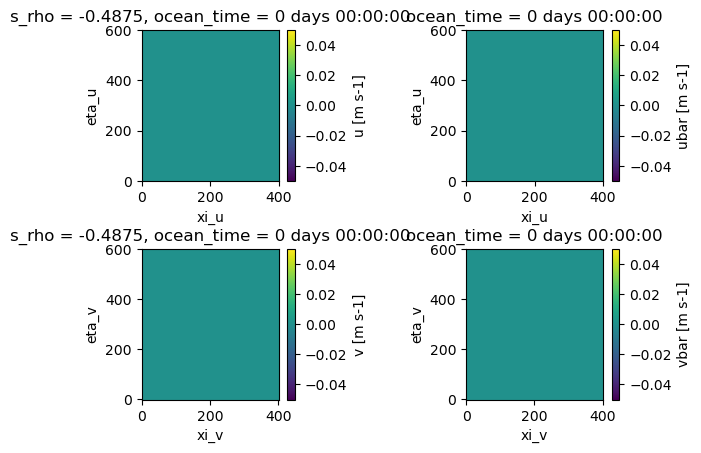

In [13]:
# Plot this to see if it worked
fig, ax = plt.subplots(2, 2)

# u currents
new_ini.u[0,20,:,:].plot(ax=ax[0,0])

# ubar
new_ini.ubar[0,:,:].plot(ax=ax[0,1])

# v currents
new_ini.v[0,20,:,:].plot(ax=ax[1,0])

# vbar
new_ini.vbar[0,:,:].plot(ax=ax[1,1])

fig.subplots_adjust(hspace=0.45, wspace=0.89)

In [14]:
# Save this to a netcdf
#new_ini.to_netcdf('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/ini_ice_500m_span_300km_004_zero_currents.nc')

<span style="color:olivedrab"> **Option 3** </span>   
Make them based on real data so would need to (potentially redownload HYCOM data), then choose conditions in October (maybe take the average over time? Then interpolate onto our grid?), then put those for salt, temp, u, v, ubar, vbar?

Or have other ways of taking one time stamp for conditions we like  

(I think this is the ultimate goal for another simulation but first do a simpler version to see if this even impacts the line formation)

### <span style="color:gold"> Surface Forcings </span>

In [4]:
# Load in the surface forcings to see what they are set to 
og_surf_forc = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_updated_scratch/Forcing_files/idealized_const_forcing_500m_span_300km_001.nc')

In [5]:
og_surf_forc

<xarray.Dataset> Size: 119GB
Dimensions:     (xi_rho: 402, eta_rho: 602, tair_time: 8784, pair_time: 8784,
                 qair_time: 8784, rain_time: 8784, cloud_time: 8784,
                 lrf_time: 8784, srf_time: 8784)
Coordinates:
  * xi_rho      (xi_rho) float64 3kB 0.0 1.0 2.0 3.0 ... 398.0 399.0 400.0 401.0
  * eta_rho     (eta_rho) float64 5kB 0.0 1.0 2.0 3.0 ... 599.0 600.0 601.0
  * tair_time   (tair_time) float64 70kB 0.0 8.64e+04 ... 7.588e+08 7.589e+08
  * pair_time   (pair_time) float64 70kB 0.0 8.64e+04 ... 7.588e+08 7.589e+08
  * qair_time   (qair_time) float64 70kB 0.0 8.64e+04 ... 7.588e+08 7.589e+08
  * rain_time   (rain_time) float64 70kB 0.0 8.64e+04 ... 7.588e+08 7.589e+08
  * cloud_time  (cloud_time) float64 70kB 0.0 8.64e+04 ... 7.588e+08 7.589e+08
  * lrf_time    (lrf_time) float64 70kB 0.0 8.64e+04 ... 7.588e+08 7.589e+08
  * srf_time    (srf_time) float64 70kB 0.0 8.64e+04 ... 7.588e+08 7.589e+08
Data variables:
    Tair        (tair_time, eta_rho, xi_rho) float64 17GB ...
    Pair        (pair_time, eta_rho, xi_rho) float64 17GB ...
    Qair        (qair_time, eta_rho, xi_rho) float64 17GB ...
    rain        (rain_time, eta_rho, xi_rho) float64 17GB ...
    cloud       (cloud_time, eta_rho, xi_rho) float64 17GB ...
    lwrad_down  (lrf_time, eta_rho, xi_rho) float64 17GB ...
    swrad       (srf_time, eta_rho, xi_rho) float64 17GB ...
Attributes:
    gridname:     *.nc
    type:         ROMS grid shaped ERA5 idealized constant forcing
    history:      Created by Brianna Undzis
    Conventions:  CF
    Institution:  University of Colorado Boulder
    date:         2026-04-09 12:28:04.231184

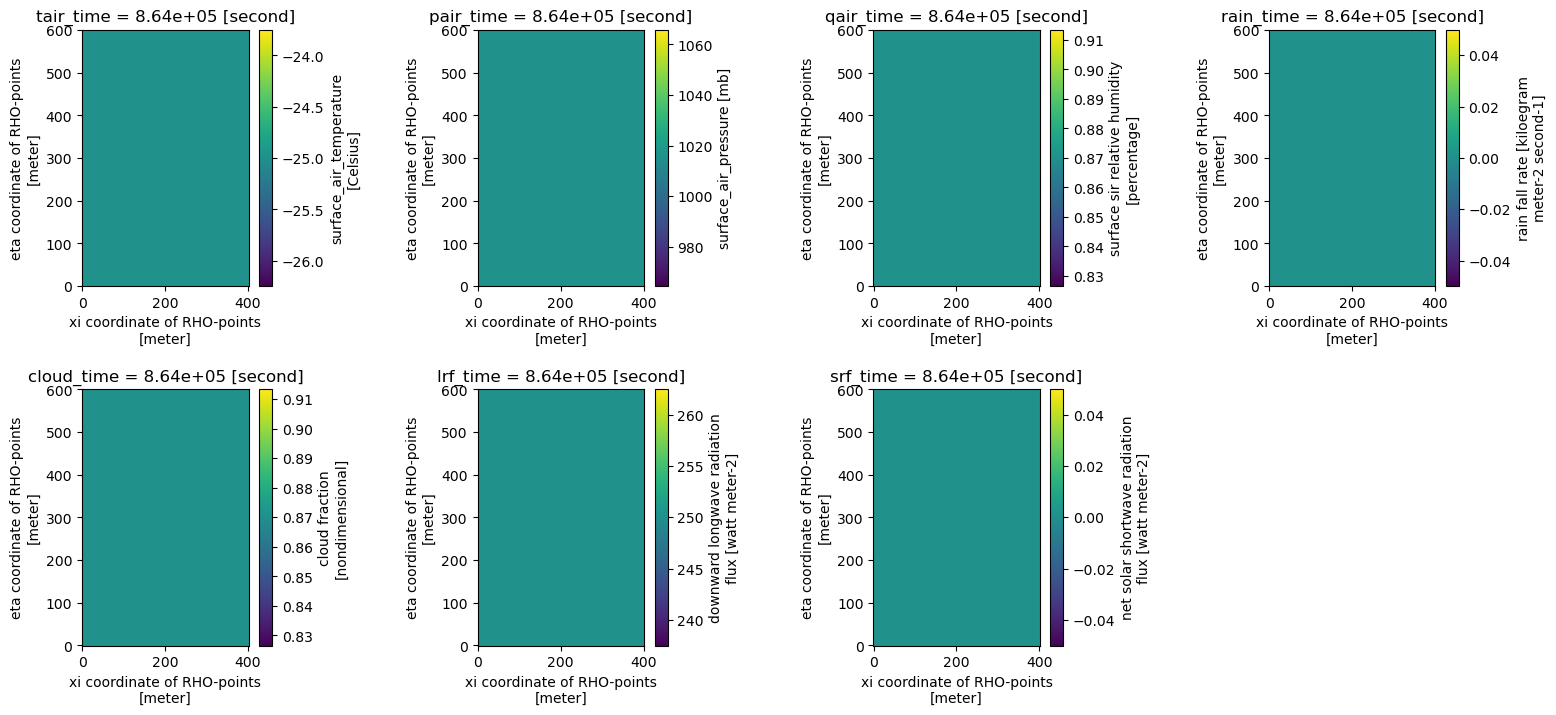

In [13]:
# Plot these inputs to see what they look like
fig, ax = plt.subplots(2, 4, figsize=(18,8))

# Tair
og_surf_forc.Tair[10,:,:].plot(ax=ax[0,0])

# Pair 
og_surf_forc.Pair[10,:,:].plot(ax=ax[0,1])

# Qair
og_surf_forc.Qair[10,:,:].plot(ax=ax[0,2])

# rain
og_surf_forc.rain[10,:,:].plot(ax=ax[0,3])

# cloud
og_surf_forc.cloud[10,:,:].plot(ax=ax[1,0])

# lwrad_down
og_surf_forc.lwrad_down[10,:,:].plot(ax=ax[1,1])

# swrad
og_surf_forc.swrad[10,:,:].plot(ax=ax[1,2])

# Delete unused axis
plt.delaxes(ax[1,3])


fig.subplots_adjust(hspace=0.4, wspace=0.9)


In [15]:
# Print the mean value for each
print('mean Tair (C): ', og_surf_forc.Tair.mean().values)
print('mean Pair (mb): ', og_surf_forc.Pair.mean().values)
print('mean Qair (%): ', og_surf_forc.Qair.mean().values)
print('mean rain (m-2s-1): ', og_surf_forc.rain.mean().values)
print('mean cloud (nondimensional): ', og_surf_forc.cloud.mean().values)
print('mean lwrad_down (W/m2): ', og_surf_forc.lwrad_down.mean().values)
print('mean swrad (W/m2): ', og_surf_forc.swrad.mean().values)

mean Tair (C):  -25.0
mean Pair (mb):  1015.1399999932637
mean Qair (%):  0.8699999999970272
mean rain (m-2s-1):  0.0
mean cloud (nondimensional):  0.8699999999970272
mean lwrad_down (W/m2):  250.0
mean swrad (W/m2):  0.0


**Temperature**

In [ ]:
# Since temperature is the first one to get all wonky, what if we 
# try a different constant temperature?
# Even if it is not cold enough to make ice form, just to see if this
# is related to the lines at all/if they persist under warmer temperatures 

In [18]:
# Set a new constant temperature to set the forcing to
# (picking a warmer value that is above 0 just to see
# if that matters...even if it is not realistic for us)
new_Tair_const = 10 # Celsius

# Make an array that is the right shape with this
new_Tair_arr = np.full_like((og_surf_forc.Tair), new_Tair_const)

In [19]:
# Make a new dataset to save this to 
new_surf_forc = og_surf_forc.copy()

In [20]:
# Replace Tair with the new constant value
new_surf_forc['Tair'].values = new_Tair_arr

In [21]:
# Now save this to a net netCDF
#new_surf_forc.to_netcdf('/global/u2/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/idealized_const_forcing_500m_span_300km_001_warm_Tair.nc')

In [22]:
# Load this in to make sure it worked
surf_forc_check = xr.open_dataset('/global/u2/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/idealized_const_forcing_500m_span_300km_001_warm_Tair.nc')

In [23]:
# Print to check
print('new mean Tair (C): ', surf_forc_check.Tair.mean().values)

new mean Tair (C):  10.0
